In [1]:
import sys
import subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", 
    "pandas", "numpy", "matplotlib", "seaborn", 
    "sqlalchemy==1.4.46", "psycopg2-binary", "python-dotenv"])

0

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv('../.env.local')
engine = create_engine(os.getenv('DATABASE_URL'))

plt.style.use('seaborn-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 120

print("Connected!")

Connected!


# Wind Power Reliability Analysis — UK (January 2024)

## Problem Statement
Wind power is unpredictable. Unlike gas or nuclear, you cannot turn it up on demand. Grid operators need to know how much wind capacity they can actually count on, meaning how much is almost always available even on bad days.

## The Core Question
How many MW of wind power can we reliably expect to be there when demand needs it?

## My Approach
This is a percentile problem. Saying "X MW is reliable" means wind generation drops below X MW only rarely. I will look at the full distribution of actual generation, see how often it falls very low, and then pick a confidence threshold to make a practical recommendation.

## My Initial Hypothesis
January is a windy month in the UK, so I would expect typical generation to sit somewhere between 5,000 and 12,000 MW for most hours. Very low output periods do happen, usually during high-pressure weather systems when wind across the country drops at the same time.
For reliability, I would set the bar at the 10th percentile, meaning the level that wind meets or exceeds 90% of the time. A 95% threshold feels too conservative for planning purposes, but 90% gives grid operators a number they can build around without over-relying on best-case conditions.

In [4]:
with engine.connect() as conn:
    df = pd.read_sql("""
        SELECT start_time, generation::float AS actual_mw
        FROM actuals
        ORDER BY start_time
    """, conn)

df['start_time'] = pd.to_datetime(df['start_time'], utc=True)
df['hour'] = df['start_time'].dt.hour
df['date'] = df['start_time'].dt.date
df['day_of_week'] = df['start_time'].dt.day_name()

print(f"Total records: {len(df)}")
print(f"Date range: {df['start_time'].min()} to {df['start_time'].max()}")
print()
print("Basic statistics:")
print(df['actual_mw'].describe().round(1))

Total records: 1489
Date range: 2023-12-31 23:30:00+00:00 to 2024-01-31 23:30:00+00:00

Basic statistics:
count     1489.0
mean      9848.8
std       3674.8
min          0.0
25%       6733.0
50%       9883.0
75%      13105.0
max      16662.0
Name: actual_mw, dtype: float64


## Step 1: Understanding the Distribution
The basic statistics already reveal a lot. Generation ranges from 0 MW to 16,662 MW, which is a huge swing. A standard deviation of 3,674 MW, nearly 37% of the mean, confirms just how variable wind output is. The 25th percentile sitting at 6,733 MW means wind dropped below that level one quarter of the time, which is a lot of hours for a grid operator to plan around.
The 0 MW minimum is what stands out most. It means there were periods where wind contributed essentially nothing to the grid, likely during a high-pressure system when wind dropped across the whole country at once. That is the scenario grid operators actually lose sleep over: not low wind, but near-zero wind nationwide with demand still running at full levels. In those moments, every MW of backup capacity matters.

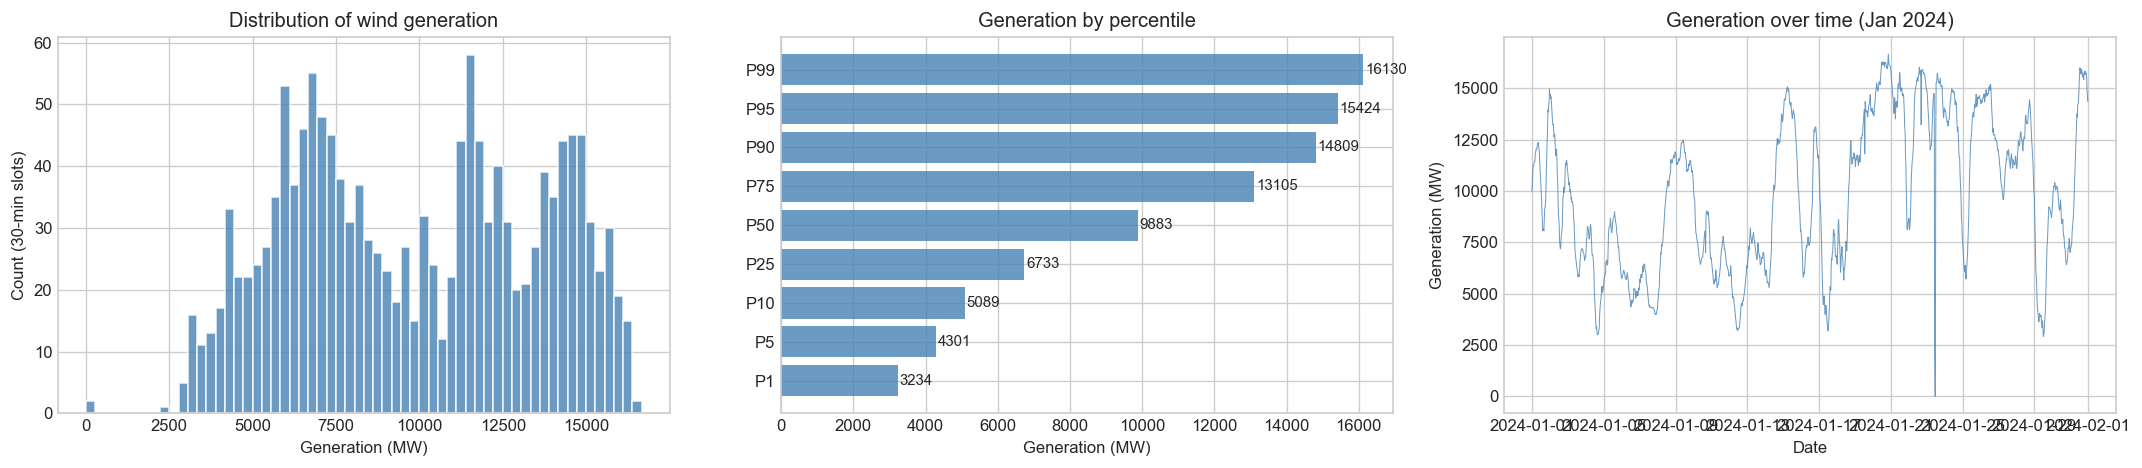


Key percentile values:
  P 1:    3234 MW  (19.4% of max)
  P 5:    4301 MW  (25.8% of max)
  P10:    5089 MW  (30.5% of max)
  P25:    6733 MW  (40.4% of max)
  P50:    9883 MW  (59.3% of max)
  P75:   13105 MW  (78.7% of max)
  P90:   14809 MW  (88.9% of max)
  P95:   15424 MW  (92.6% of max)
  P99:   16130 MW  (96.8% of max)


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Histogram
axes[0].hist(df['actual_mw'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of wind generation')
axes[0].set_xlabel('Generation (MW)')
axes[0].set_ylabel('Count (30-min slots)')

# Percentile bar chart
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
values = [df['actual_mw'].quantile(p/100) for p in percentiles]
bars = axes[1].barh([f'P{p}' for p in percentiles], values, 
                     color='steelblue', alpha=0.8)
axes[1].set_title('Generation by percentile')
axes[1].set_xlabel('Generation (MW)')
for i, v in enumerate(values):
    axes[1].text(v + 50, i, f'{v:.0f}', va='center', fontsize=9)

# Time series
axes[2].plot(df['start_time'], df['actual_mw'], 
             linewidth=0.6, color='steelblue', alpha=0.8)
axes[2].set_title('Generation over time (Jan 2024)')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Generation (MW)')

plt.tight_layout()
plt.show()

print("\nKey percentile values:")
for p, v in zip(percentiles, values):
    pct_of_max = (v / df['actual_mw'].max()) * 100
    print(f"  P{p:2d}: {v:7.0f} MW  ({pct_of_max:.1f}% of max)")

## What the distribution tells us
The histogram shows a bimodal pattern. Generation in January 2024 clustered in two bands: around 5,000-7,000 MW and 11,000-14,000 MW. Wind was mostly either on or off, with few hours in between.
The time series adds something important: low-output periods were not brief dips but sustained stretches lasting multiple days, which means backup capacity has to be available for days, not just hours.
Key percentile markers:

P1: 3,234 MW
P5: 4,301 MW
P10: 5,089 MW

P10 feels like the right threshold. P5 or P1 would mean keeping huge amounts of backup capacity on standby for events that almost never happen. P10 still represents a real stress scenario but is practical to plan around. If the grid can cover demand when wind sits at 5,089 MW, it is in reasonable shape for most of what January throws at it.

In [6]:
thresholds = [1000, 2000, 3000, 4000, 5000, 6000]

print(f"{'Threshold':>12} {'Hours below':>12} {'% of time':>10} {'Longest stretch':>16}")
print("-" * 55)

for t in thresholds:
    below = df['actual_mw'] < t
    hrs = below.sum() * 0.5
    pct = (below.sum() / len(df)) * 100

    # Find longest consecutive stretch below threshold
    streak = max_streak = 0
    for b in below:
        if b:
            streak += 1
            max_streak = max(max_streak, streak)
        else:
            streak = 0

    print(f"{t:>10} MW {hrs:>10.0f}h {pct:>9.1f}%  {max_streak * 0.5:>12.1f}h")

   Threshold  Hours below  % of time  Longest stretch
-------------------------------------------------------
      1000 MW          1h       0.1%           1.0h
      2000 MW          1h       0.1%           1.0h
      3000 MW          2h       0.3%           1.5h
      4000 MW         28h       3.8%           7.5h
      5000 MW         71h       9.5%          16.0h
      6000 MW        127h      17.1%          20.0h


## Step 2: How Often Does Wind Drop Low?

The most useful column here is the longest stretch, not just total hours. Knowing wind drops below a threshold 28 times is less useful than knowing it can stay there for 7.5 hours straight, because backup generation needs time to ramp up and hold.
Below 4,000 MW: 28 hours total, longest stretch 7.5 hours. Rare enough to handle with fast-response backup like batteries or pumped hydro.
Below 5,000 MW: 71 hours total, longest stretch 16 hours. Nearly two thirds of a day with wind below 5,000 MW. That requires sustained backup, not just a quick response.
Below 6,000 MW: 127 hours, longest stretch 20 hours. This happens often enough that it cannot be treated as an edge case.
The 5,000 MW threshold feels like the right planning boundary. It is the point where the duration becomes long enough to stress the system. A 16-hour low-wind period would need something like gas peakers or interconnector imports that can run for extended periods, not just short-burst storage. Batteries help at the margins but a stretch that long requires dispatchable capacity that can sustain output across a full day and night.

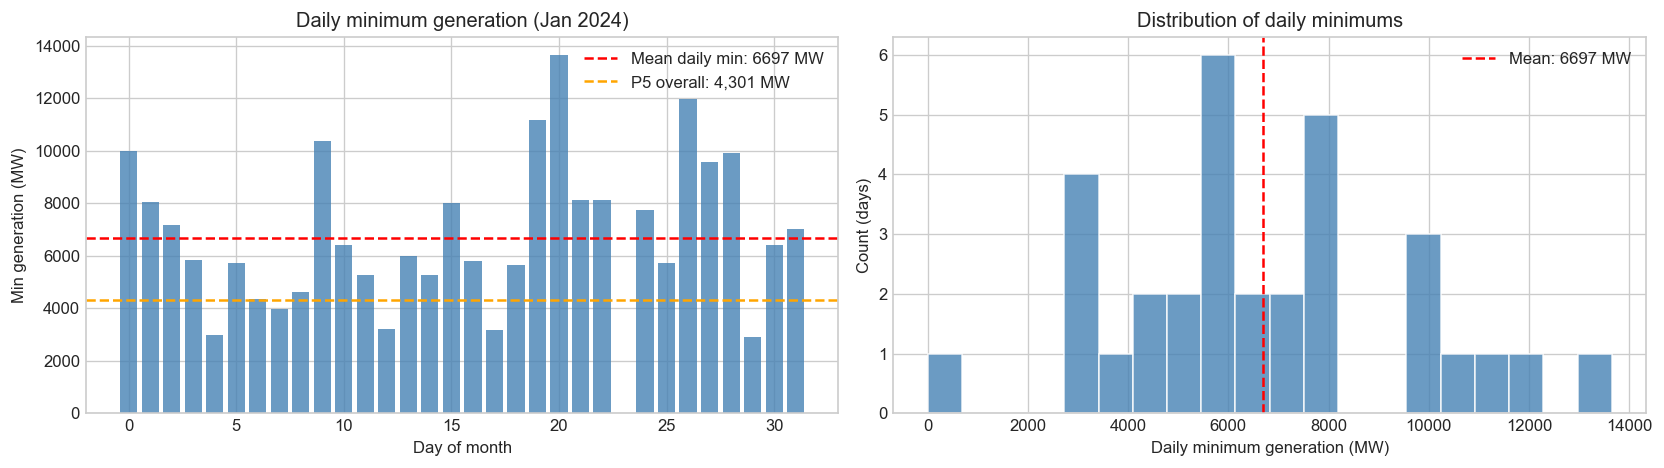

Lowest daily minimum:  0 MW on 2024-01-23
Average daily minimum: 6697 MW
P10 of daily minimums: 3181 MW
Days below 4000 MW minimum: 6 days
Days below 5000 MW minimum: 8 days


In [7]:
# Daily minimum analysis
daily_min = df.groupby('date')['actual_mw'].min().reset_index()
daily_min.columns = ['date', 'daily_min_mw']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(len(daily_min)), daily_min['daily_min_mw'], 
            color='steelblue', alpha=0.8)
axes[0].axhline(daily_min['daily_min_mw'].mean(), color='red', 
                linestyle='--', linewidth=1.5,
                label=f"Mean daily min: {daily_min['daily_min_mw'].mean():.0f} MW")
axes[0].axhline(4301, color='orange', linestyle='--', linewidth=1.5,
                label=f"P5 overall: 4,301 MW")
axes[0].set_title('Daily minimum generation (Jan 2024)')
axes[0].set_xlabel('Day of month')
axes[0].set_ylabel('Min generation (MW)')
axes[0].legend()

axes[1].hist(daily_min['daily_min_mw'], bins=20, 
             color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(daily_min['daily_min_mw'].mean(), color='red', 
                linestyle='--', linewidth=1.5,
                label=f"Mean: {daily_min['daily_min_mw'].mean():.0f} MW")
axes[1].set_title('Distribution of daily minimums')
axes[1].set_xlabel('Daily minimum generation (MW)')
axes[1].set_ylabel('Count (days)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Lowest daily minimum:  {daily_min['daily_min_mw'].min():.0f} MW on {daily_min.loc[daily_min['daily_min_mw'].idxmin(), 'date']}")
print(f"Average daily minimum: {daily_min['daily_min_mw'].mean():.0f} MW")
print(f"P10 of daily minimums: {daily_min['daily_min_mw'].quantile(0.10):.0f} MW")
print(f"Days below 4000 MW minimum: {(daily_min['daily_min_mw'] < 4000).sum()} days")
print(f"Days below 5000 MW minimum: {(daily_min['daily_min_mw'] < 5000).sum()} days")

## Step 3: Daily Minimum Analysis

Looking at the worst point each day tells a harder story than the overall percentiles. Six out of 31 days saw their daily minimum drop below 4,000 MW. That is nearly 20% of days, so grid operators cannot treat it as a rare event. It needs planned backup capacity, full stop.

January 23rd recorded 0 MW at some point. Brief as it was, that is the scenario backup systems have to be built for.

The P10 of daily minimums is 3,181 MW, meaning on the worst 10% of days, wind dropped to around 3,200 MW or lower at its worst point. The average daily minimum of 6,697 MW sounds more reassuring, but grid planning cannot be built around averages.

The 0 MW reading on January 23rd does change how you think about reliability. The average daily minimum of 6,697 MW offers some comfort at a surface level, but a single day of complete wind failure is enough to set the floor for what backup systems need to handle. Planning around the average means being unprepared for the days that actually test the grid.

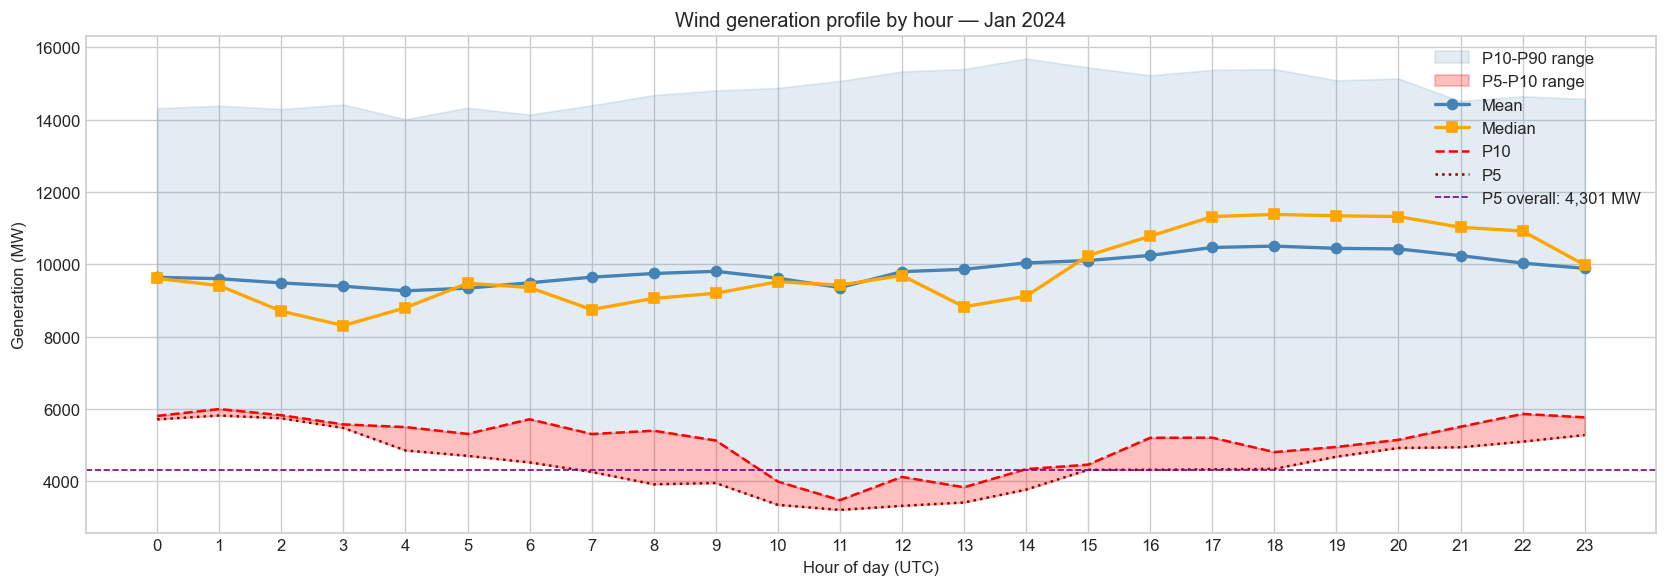

Hourly P5 and P10 values:
 Hour    P5 (MW)   P10 (MW)  Mean (MW)
----------------------------------------
  00:00       5710       5805       9638
  01:00       5816       5995       9599
  02:00       5739       5824       9482
  03:00       5472       5571       9391
  04:00       4850       5496       9264
  05:00       4700       5308       9338
  06:00       4519       5713       9487
  07:00       4255       5305       9642
  08:00       3913       5396       9743
  09:00       3949       5126       9804
  10:00       3345       3990       9611
  11:00       3205       3476       9355
  12:00       3318       4118       9795
  13:00       3410       3832       9859
  14:00       3766       4334      10036
  15:00       4316       4457      10102
  16:00       4315       5199      10244
  17:00       4329       5204      10463
  18:00       4340       4805      10501
  19:00       4677       4946      10439
  20:00       4918       5144      10423
  21:00       4937       5506    

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))

hourly_profile = df.groupby('hour')['actual_mw'].agg(
    mean='mean',
    median='median',
    p10=lambda x: x.quantile(0.10),
    p90=lambda x: x.quantile(0.90),
    p5=lambda x: x.quantile(0.05),
).reset_index()

ax.fill_between(hourly_profile['hour'], hourly_profile['p10'], 
                hourly_profile['p90'], alpha=0.15, color='steelblue', 
                label='P10-P90 range')
ax.fill_between(hourly_profile['hour'], hourly_profile['p5'], 
                hourly_profile['p10'], alpha=0.25, color='red', 
                label='P5-P10 range')
ax.plot(hourly_profile['hour'], hourly_profile['mean'], 
        marker='o', color='steelblue', linewidth=2, label='Mean')
ax.plot(hourly_profile['hour'], hourly_profile['median'], 
        marker='s', color='orange', linewidth=2, label='Median')
ax.plot(hourly_profile['hour'], hourly_profile['p10'], 
        color='red', linewidth=1.5, linestyle='--', label='P10')
ax.plot(hourly_profile['hour'], hourly_profile['p5'], 
        color='darkred', linewidth=1.5, linestyle=':', label='P5')

ax.axhline(4301, color='purple', linewidth=1, linestyle='--', 
           label='P5 overall: 4,301 MW')

ax.set_xlabel('Hour of day (UTC)')
ax.set_ylabel('Generation (MW)')
ax.set_title('Wind generation profile by hour — Jan 2024')
ax.set_xticks(range(0, 24))
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

print("Hourly P5 and P10 values:")
print(f"{'Hour':>5} {'P5 (MW)':>10} {'P10 (MW)':>10} {'Mean (MW)':>10}")
print("-" * 40)
for _, row in hourly_profile.iterrows():
    print(f"  {int(row['hour']):02d}:00 {row['p5']:>10.0f} {row['p10']:>10.0f} {row['mean']:>10.0f}")

## Step 4: Hourly Reliability Profile
Reliability is not uniform across the day. The P5 floor drops during midday hours (10:00-13:00 UTC), reaching as low as 3,205 MW at 11:00 UTC. Overnight hours are more stable at the low end, with P5 values above 5,700 MW.This matters because UK demand peaks in the morning (07:00-09:00 UTC) and evening (17:00-19:00 UTC). The morning peak coincides with a P5 of roughly 3,900-4,300 MW, meaning on the worst 5% of mornings, wind is contributing less than 4,000 MW right when demand is highest. The evening peak looks safer, with P5 values around 4,300-4,800 MW.This hourly pattern does shift the reliability recommendation. A single number like P10 across all hours hides the fact that midday and morning hours carry more risk. A grid operator would be better served by hour-specific reliability figures rather than one flat threshold, and backup capacity planning should account for the morning peak being the most exposed window of the day.

In [9]:
print("=" * 55)
print("RELIABILITY ANALYSIS SUMMARY")
print("=" * 55)

print("\nOVERALL DISTRIBUTION")
print(f"  Mean generation:      {df['actual_mw'].mean():>8.0f} MW")
print(f"  Median generation:    {df['actual_mw'].median():>8.0f} MW")
print(f"  Min generation:       {df['actual_mw'].min():>8.0f} MW")
print(f"  Max generation:       {df['actual_mw'].max():>8.0f} MW")

print("\nRELIABILITY THRESHOLDS")
for p in [1, 5, 10, 25]:
    val = df['actual_mw'].quantile(p/100)
    pct_time_above = ((df['actual_mw'] >= val).sum() / len(df)) * 100
    print(f"  P{p:2d}: {val:>7.0f} MW  (above this {pct_time_above:.1f}% of the time)")

print("\nDAILY MINIMUM STATISTICS")
print(f"  Average daily min:    {daily_min['daily_min_mw'].mean():>8.0f} MW")
print(f"  P10 of daily mins:    {daily_min['daily_min_mw'].quantile(0.10):>8.0f} MW")
print(f"  Days below 4000 MW:   {(daily_min['daily_min_mw'] < 4000).sum():>8d} days out of {len(daily_min)}")
print(f"  Days below 5000 MW:   {(daily_min['daily_min_mw'] < 5000).sum():>8d} days out of {len(daily_min)}")

print("\nWORST CASE HOUR (10:00-13:00 UTC WINDOW)")
worst_window = hourly_profile[hourly_profile['hour'].between(10, 13)]
print(f"  Lowest P5 in window:  {worst_window['p5'].min():>8.0f} MW")
print(f"  Lowest P10 in window: {worst_window['p10'].min():>8.0f} MW")

RELIABILITY ANALYSIS SUMMARY

OVERALL DISTRIBUTION
  Mean generation:          9849 MW
  Median generation:        9883 MW
  Min generation:              0 MW
  Max generation:          16662 MW

RELIABILITY THRESHOLDS
  P 1:    3234 MW  (above this 99.0% of the time)
  P 5:    4301 MW  (above this 95.0% of the time)
  P10:    5089 MW  (above this 90.0% of the time)
  P25:    6733 MW  (above this 75.0% of the time)

DAILY MINIMUM STATISTICS
  Average daily min:        6697 MW
  P10 of daily mins:        3181 MW
  Days below 4000 MW:          6 days out of 32
  Days below 5000 MW:          8 days out of 32

WORST CASE HOUR (10:00-13:00 UTC WINDOW)
  Lowest P5 in window:      3205 MW
  Lowest P10 in window:     3476 MW


# Final Recommendation

## Recommended reliable figure: 4,301 MW (P5)
I recommend 4,301 MW as the firm wind contribution figure for grid planning. This is the P5 value, meaning wind was at or above this level 95% of the time in January 2024.

## Why P5 and not P10? 

The daily minimum analysis shows 8 out of 32 days had their lowest point below 5,000 MW. Using P10 as the baseline would mean the grid falls short one in four days, which is too often. P5 brings that down to roughly 1-2 days per month, which is a more honest number to plan around.

## The 0 MW event on January 23rd 

No reliability figure protects against complete wind failure. The 4,301 MW recommendation means 95% confidence, not 100%. The remaining 5% requires fast-response backup: gas peakers, batteries, or interconnector imports.

## Morning peak caveat 

The hourly analysis shows P5 dropping to 3,205-3,410 MW during 10:00-13:00 UTC, which is below the recommended figure. An operator focused on daytime reliability might prefer a lower planning figure of around 3,500 MW for those hours specifically.

## Required backup capacity 

A grid committing to 4,301 MW of firm wind needs at least 4,500-5,000 MW of dispatchable backup to cover the worst-case gap.

## Caveats

- January is one of the windiest months in the UK. Summer data would likely produce a lower and more conservative reliability figure.
- One year of data is not enough to draw firm long-term conclusions.
- UK wind capacity grows year on year, so these absolute MW figures will shift.
- This analysis looks at generation in isolation, not against actual demand.

## What would strengthen this analysis

- 5-10 years of historical data
- Offshore vs onshore breakdown
- Seasonal analysis to find the worst months
- Comparison against demand to find the hours where the gap is largest







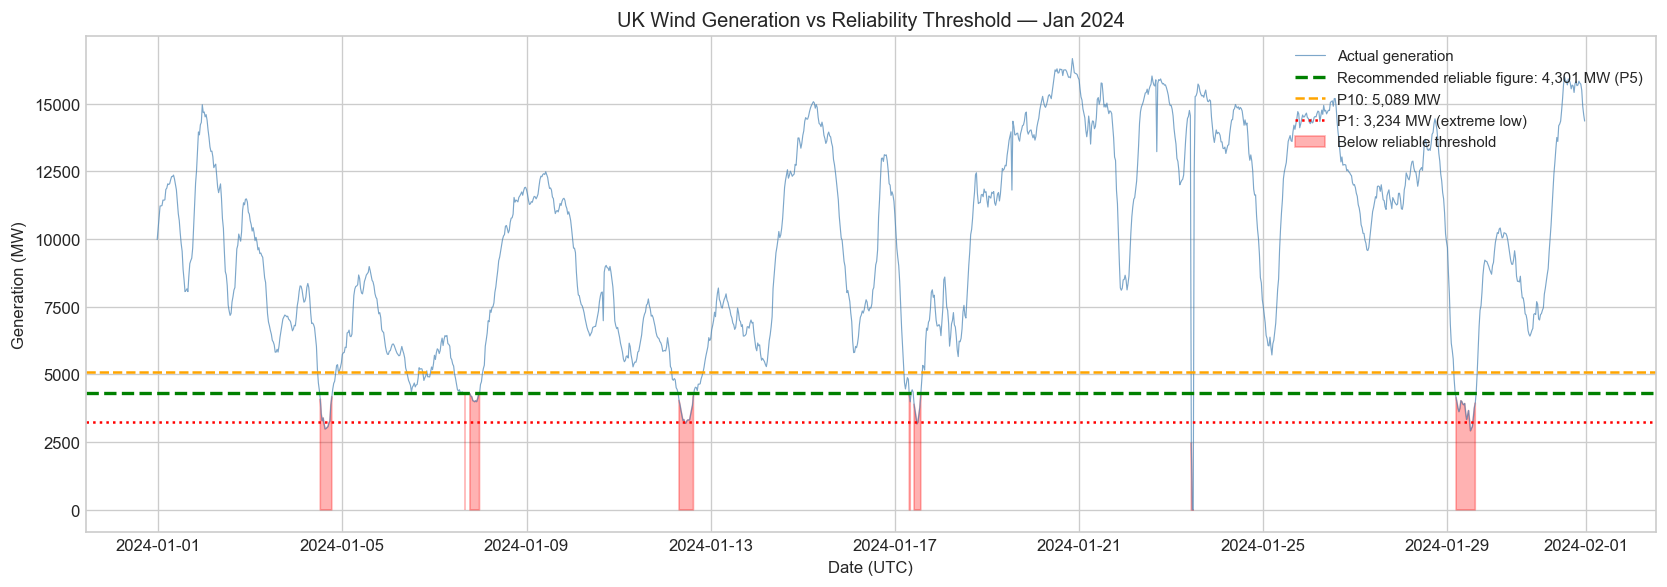

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df['start_time'], df['actual_mw'], 
        linewidth=0.7, color='steelblue', alpha=0.7, label='Actual generation')

ax.axhline(4301, color='green', linewidth=2, linestyle='--', 
           label='Recommended reliable figure: 4,301 MW (P5)')
ax.axhline(5089, color='orange', linewidth=1.5, linestyle='--', 
           label='P10: 5,089 MW')
ax.axhline(3234, color='red', linewidth=1.5, linestyle=':', 
           label='P1: 3,234 MW (extreme low)')

# Shade periods below the recommended figure
below = df['actual_mw'] < 4301
ax.fill_between(df['start_time'], 0, df['actual_mw'], 
                where=below, color='red', alpha=0.3, 
                label='Below reliable threshold')

ax.set_xlabel('Date (UTC)')
ax.set_ylabel('Generation (MW)')
ax.set_title('UK Wind Generation vs Reliability Threshold — Jan 2024')
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()